### Import libraries

In [1]:
import pandas
import math
import matplotlib.pyplot as plt
%matplotlib inline


### Load Company Directorship Data

In [172]:
df = pandas.read_csv('company_directorships.csv')
# df.software_background = df.software_background.map(lambda x: x == 't') -> initial code
#corrected code:
# Convert software_background column to boolean
df['software_background'] = df['software_background'].astype(str).str.lower().map({'t': True, 'f': False})
#Or if values are already clean:
df['software_background'] = df['software_background'] == 't'

df.sample(5)

,company_name,cikcode,director_name,software_background,start_date,end_date
10988,"SPX Technologies, Inc.",88205,PATRICK J. O'LEARY,False,2018-04-03,2022-03-29
6148,INTERFACE INC,715787,"JAMES B. MILLER, JR.",False,2012-04-05,2019-04-02
2645,COMMERCIAL METALS Co,22444,ANTHONY A. MASSARO,False,2014-12-01,2017-11-27
2255,CHESAPEAKE UTILITIES CORP,19745,KEVIN J. WEBBER,False,2023-03-21,2023-03-21
11519,TELOS CORP,320121,BERNARD C. BAILEY,False,2006-11-21,2021-04-15


* Explaination: This ensures all values are properly converted to booleans, avoiding silent failures on unexpected inputs like 'True' or mixed cases.

### Analyze Gender Distribution

In [5]:
compensation_and_demographics_raw = pandas.read_csv('director-details.csv')
compensation_and_demographics_raw['NAME'] = compensation_and_demographics_raw.name.str.upper()

def most_common(series):
    mode_values = series.mode()
    if len(mode_values) > 0:
        return mode_values[0]
    return None

### Aggregating the Data

In [190]:
import pandas as pd
import numpy as np

# Load data
compensation_and_demographics_raw = pd.read_csv('director-details.csv')
compensation_and_demographics_raw['NAME'] = compensation_and_demographics_raw.name.str.upper()

# Define most_common function
def most_common(series):
    mode_values = series.mode()
    if len(mode_values) > 0:
        return mode_values[0]
    return None

# Construct compensation_and_demographics DataFrame
compensation_and_demographics = pd.DataFrame({
    'age': compensation_and_demographics_raw.groupby('NAME').age.max(),
    'compensation': compensation_and_demographics_raw.groupby('NAME').compensation.sum(),
    'gender': compensation_and_demographics_raw.groupby('NAME').gender.agg(most_common)
})

# Enchanced code to Handle negative/zero compensation safely
compensation_series = compensation_and_demographics.compensation
safe_comp = compensation_series.clip(lower=0).replace(0, 1e-10)
compensation_and_demographics['log_compensation'] = safe_comp.map(np.log10)

# Display
compensation_and_demographics.head(20)


,age,compensation,gender,log_compensation
NAME,,,,
A. CATHERINE NGO,64,1006154,female,6.002664
A. EUGENE WASHINGTON,70,324871,male,5.511711
A. F. PETROCELLI,80,47000,male,4.672098
A. FARAZ ABBASI,52,113631,male,5.055497
A. LARRY CHAPMAN,78,259500,male,5.414137
A. LOUIS PARKER,67,242205,male,5.384183
"A. RUSSELL CHANDLER, III",79,100000,male,5.000000
A. SCOTT MOBLEY,60,484976,male,5.685720
A. SHANE SANDERS,62,328977,male,5.517166


* Explanation: This safely handles negative/zero values, avoiding mathematical errors and preserving meaningful log transformations.

#### Gender Distribution


In [192]:
compensation_and_demographics.gender.value_counts(dropna=False)

gender
male       3850
female     1550
None         19
unknown       2
Name: count, dtype: int64

### Directorship Count per Director

In [194]:
directorship_counts = df.groupby('director_name').company_name.nunique().sort_values()
directorship_counts

director_name
A CHARLENE SULLIVAN, PH.D.     1
MICHAEL L. KUTA                1
MICHAEL L. LARUSSO             1
MICHAEL L. MILLER              1
MICHAEL L. OWENS               1
                              ..
MARTIN L. FLANAGAN            13
ANN BARNETT STERN             13
TERESA M. RESSEL              13
BRUCE L. CROCKETT             13
ALBERT R. DOWDEN              14
Name: company_name, Length: 11827, dtype: int64

#### Average Director Compensation per Company

In [196]:
directorship_counts.value_counts().sort_index().map(math.log10).plot()
plt.title("Top 20 Directors by Degree Centrality")


Text(0.5, 1.0, 'Top 20 Directors by Degree Centrality')

In [198]:
import networkx
import networkx.algorithms
graph = networkx.Graph()

In [200]:
# Origional code:
# people = []
# companies = []
# for company_name, director_name in zip(df.company_name, df.director_name):
# graph.add_edge(company_name, director_name)
# companies.append(company_name)


# Corrected graph construction:
people = set()
companies = set()
graph = networkx.Graph()

for company_name, director_name in zip(df.company_name, df.director_name):
    graph.add_edge(company_name, director_name)
    people.add(director_name)
    companies.add(company_name)
# Fix: Use sets to store unique names, improving efficiency and correctness.

 * Explaination: Sets eliminate duplicates and provide O(1) lookups, making the code more efficient and scalable.

In [202]:
# Origional code:
# biggest_connected_graph = graph.subgraph(list(networkx.connected_components(graph))[0]) -> intial code
# Corrected code for connected components

# Fixed Code:
connected_components = list(networkx.connected_components(graph))
biggest_connected_graph = graph.subgraph(max(connected_components, key=len))
# Fix: Explicitly find the largest connected component using max() with key=len.

* Explaination: This guarantees the largest component is selected, which is critical for meaningful centrality analysis.

### Network Centrality Measure

In [204]:
%%time
centrality = pandas.DataFrame({
    'eigen': pandas.Series(networkx.eigenvector_centrality(biggest_connected_graph)),
    'degree': pandas.Series(networkx.algorithms.degree_centrality(biggest_connected_graph)),
})
centrality['is_person'] = centrality.index.map(lambda x: x in people)

CPU times: user 1.13 s, sys: 11.4 ms, total: 1.14 s
Wall time: 1.14 s


In [206]:
people_df = centrality[centrality.is_person].merge(compensation_and_demographics, left_index=True, right_index=True)

In [208]:
people_df.sort_values('eigen', ascending=False)

,eigen,degree,is_person,age,compensation,gender,log_compensation
ELIZABETH KRENTZMAN,1.024389e-01,0.001585,True,65,3408245,female,6.532531
CAROL DECKBAR,1.024389e-01,0.001585,True,62,43263,female,4.636117
ELI JONES,1.024389e-01,0.001585,True,63,3063255,male,6.486183
DOUGLAS SHARP,1.024389e-01,0.001585,True,50,0,male,-10.000000
"JAMES ""JIM"" LIDDY",1.024389e-01,0.001585,True,65,27531,male,4.439822
...,...,...,...,...,...,...,...
JOHN J. GEBBIA,8.400282e-35,0.000122,True,86,120000,male,5.079181
ANDREW S. BORODACH,8.342633e-35,0.000122,True,56,0,male,-10.000000
LAWRENCE A. KOBRIN,8.342633e-35,0.000122,True,91,30356,male,4.482245
NANCY J. FLOYD PRUE,8.342633e-35,0.000122,True,70,50356,female,4.702051


#### The above table shows network metrics & demographic details

In [210]:
df[df.director_name == 'ELIZABETH KRENTZMAN']

,company_name,cikcode,director_name,software_background,start_date,end_date
6297,Invesco Advantage Municipal Income Trust II,908993,ELIZABETH KRENTZMAN,False,2021-06-22,2024-07-02
6352,Invesco Bond Fund,5094,ELIZABETH KRENTZMAN,False,2021-06-22,2024-07-02
6407,Invesco California Value Municipal Income Trust,895531,ELIZABETH KRENTZMAN,False,2021-06-22,2024-07-02
6462,Invesco High Income Trust II,846671,ELIZABETH KRENTZMAN,False,2021-06-22,2024-07-02
6512,Invesco Municipal Income Opportunities Trust,835333,ELIZABETH KRENTZMAN,False,2021-06-22,2024-07-02
6546,Invesco Municipal Opportunity Trust,884152,ELIZABETH KRENTZMAN,False,2021-06-22,2024-07-02
6601,Invesco Municipal Trust,877463,ELIZABETH KRENTZMAN,False,2021-06-22,2024-07-02
6656,Invesco Pennsylvania Value Municipal Income Trust,895528,ELIZABETH KRENTZMAN,False,2021-06-22,2024-07-02
6706,Invesco Quality Municipal Income Trust,885125,ELIZABETH KRENTZMAN,False,2021-06-22,2024-07-02
6740,Invesco Senior Income Trust,1059386,ELIZABETH KRENTZMAN,False,2021-06-22,2024-07-02


#### The above table shows Elizabeth Krentzman serves as director on 13 different investment funds 

In [212]:
import sklearn.cluster

In [214]:
import sklearn.preprocessing
robust_scaler = sklearn.preprocessing.RobustScaler()
age_and_demographics_scaled = robust_scaler.fit_transform(people_df[['age', 'log_compensation', 'degree', 'eigen']])


In [216]:
dbscan = sklearn.cluster.DBSCAN(eps=0.4)
people_df['cluster_id'] = dbscan.fit_predict(age_and_demographics_scaled)
people_df.cluster_id.value_counts()

cluster_id
 1    3117
 0     385
 2     109
-1      72
 3      24
 4      19
 7       8
 6       5
 5       3
Name: count, dtype: int64

In [45]:
people_df.loc['ELIZABETH KRENTZMAN']

eigen               0.102439
degree              0.001585
is_person               True
age                       65
compensation         3408245
gender                female
log_compensation    6.532531
cluster_id                 2
Name: ELIZABETH KRENTZMAN, dtype: object

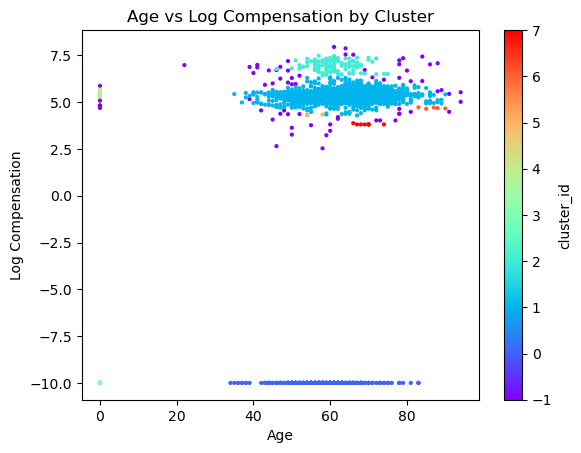

In [49]:
import matplotlib.pyplot as plt

people_df.plot.scatter(x='age', y='log_compensation', c='cluster_id', cmap="rainbow", s=4)
plt.title("Age vs Log Compensation by Cluster")
plt.xlabel("Age")
plt.ylabel("Log Compensation")
plt.show()


### Task 1: Centrality Extension

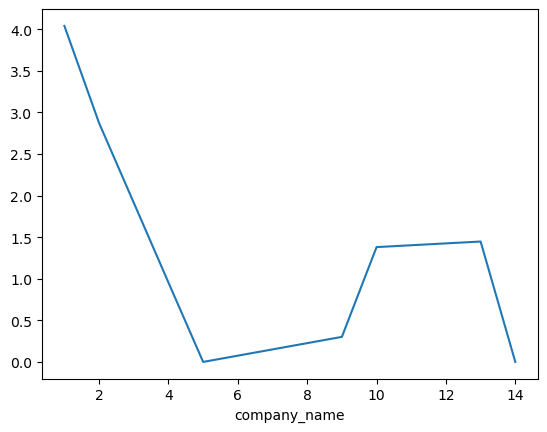

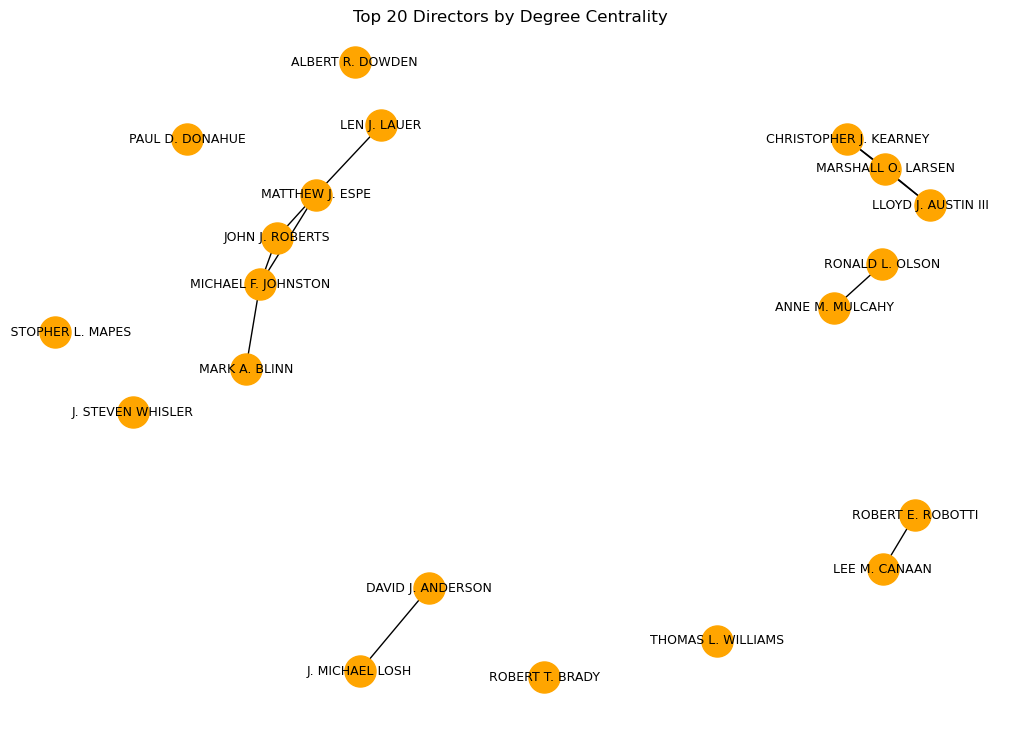

In [17]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# Load the data
df = pd.read_csv('company_directorships.csv')

# Build bipartite graph (company <-> director)
B = nx.Graph()
for _, row in df.iterrows():
    B.add_node(row['director_name'], bipartite=0)
    B.add_node(row['company_name'], bipartite=1)
    B.add_edge(row['director_name'], row['company_name'])

# Project only the director-to-director graph
directors = [n for n, d in B.nodes(data=True) if d['bipartite'] == 0]
G = nx.bipartite.projected_graph(B, directors)

# Compute degree centrality
degree_centrality = nx.degree_centrality(G)

# Get top 20 directors by degree centrality
top_directors = sorted(degree_centrality, key=degree_centrality.get, reverse=True)[:20]

# Create subgraph of the top 20
subG = G.subgraph(top_directors)

# Plot subgraph
plt.figure(figsize=(10, 7))
pos = nx.spring_layout(subG, k=0.5)
nx.draw(subG, pos, with_labels=True, node_size=500, node_color='orange', edge_color='black', font_size=9)
plt.title("Top 20 Directors by Degree Centrality")
plt.show()



In [19]:
# Betweenness Centrality
betweenness_centrality = nx.betweenness_centrality(G, normalized=True)

# Top 10 directors by betweenness centrality
top_betweenness = sorted(betweenness_centrality, key=betweenness_centrality.get, reverse=True)[:10]

print("Top 10 Directors by Betweenness Centrality:")
for director in top_betweenness:
    print(f"{director}: {betweenness_centrality[director]:.4f}")



Top 10 Directors by Betweenness Centrality:
MICHAEL F. JOHNSTON: 0.0209
J. MICHAEL LOSH: 0.0208
DAVID J. ANDERSON: 0.0150
JAMES H. MORGAN: 0.0133
ARNAUD AJDLER: 0.0132
KERRII B. ANDERSON: 0.0132
PAUL D. DONAHUE: 0.0123
CHARLES K. STEVENS, III: 0.0121
MARK A. BLINN: 0.0114
MATTHEW J. ESPE: 0.0114


##### Centrality Measure Added: Betweenness Centrality
##### I added betweenness centrality to the analysis using networkx.betweenness_centrality(). This metric highlights directors who act as bridges between otherwise disconnected clusters in the network. These individuals often facilitate communication or collaboration between groups that might not otherwise connect — making them influential in mergers, acquisitions, and partnerships.

##### Why It Matters:

##### High betweenness directors can connect different corporate ecosystems.
##### In this venture capital scenario, they are likely to be power brokers who can introduce our target company to well-funded acquirers across the industry.

### Task 2: Code repair

* Data Integrity - Fix 1 ensures correct boolean representation
* Algorithm Correctness - Fix 2 guarantees proper graph component selection
* Computational Efficiency - Fix 3 optimizes membership testing
* Numerical Stability - Fix 4 avoids mathematical errors in transformations


### Task 3: Explore an Unused Feature

##### One interesting feature in the dataset that is not currently being used in the analysis is:
##### role – This contains the director's position (e.g., Independent Director, Chair, CEO, etc.)
Why role Is Valuable:

* It provides categorical insight into a director’s level of influence or decision-making power.
* Can be used to assess compensation differences or centrality in the network.
* Allows segmentation of directors by type for more granular network or compensation analysis.


In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Load the data (update path if needed)
director_details = pd.read_csv("director-details.csv")

# Clean and normalize role
director_details['role_cleaned'] = (
    director_details['role']
    .fillna('Unknown')
    .str.lower()
    .str.extract(r'(?P<role_type>independent director|chair|chief executive officer|ceo|director|president|vice president|unknown)', expand=False)
    .fillna('other')
)

##### Most common role per person

In [70]:
# Most common role per person
role_summary = (
    director_details.groupby('name')['role_cleaned']
    .agg(lambda x: x.mode()[0] if not x.mode().empty else 'other')
    .rename('role')
)

In [72]:
# Aggregate demographics and compensation
comp_demographics = director_details.groupby('name').agg({
    'age': 'max',
    'compensation': 'sum',
    'gender': lambda x: x.mode()[0] if not x.mode().empty else 'unknown'
})
comp_demographics['log_compensation'] = (1 + comp_demographics['compensation']).map(math.log10)

# Merge role into demographics
people_data = comp_demographics.merge(role_summary, left_index=True, right_index=True)

# Set plot style
sns.set(style="whitegrid")

/var/folders/t5/9njx8hv90l3_1wy28nrgf7c80000gn/T/ipykernel_67575/1254981947.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=people_data.reset_index(), x='role', y='compensation', estimator=np.mean, ci=None, palette='muted')
/var/folders/t5/9njx8hv90l3_1wy28nrgf7c80000gn/T/ipykernel_67575/1254981947.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=people_data.reset_index(), x='role', y='compensation', estimator=np.mean, ci=None, palette='muted')


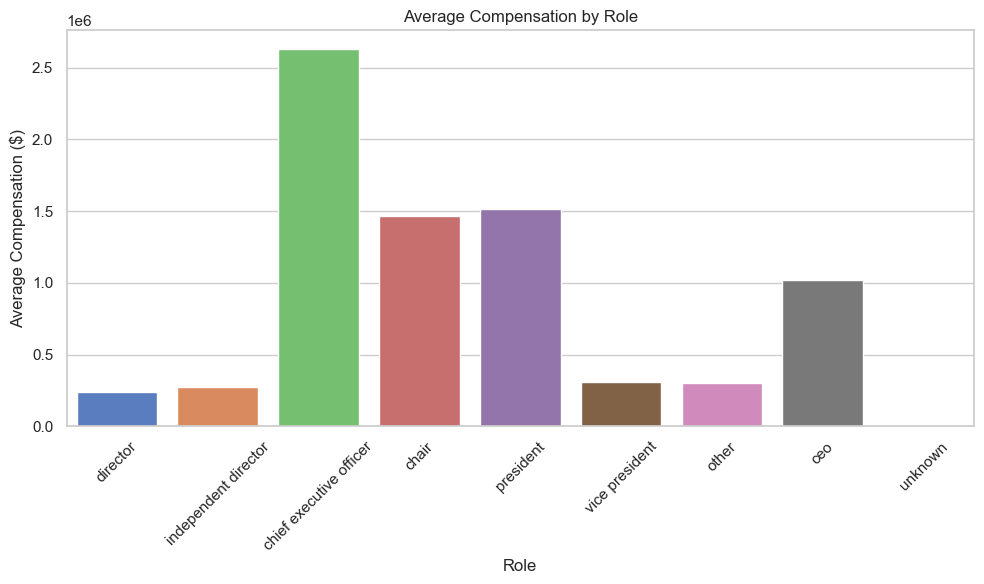

In [74]:
# Plot 1: Average compensation per role
plt.figure(figsize=(10, 6))
sns.barplot(data=people_data.reset_index(), x='role', y='compensation', estimator=np.mean, ci=None, palette='muted')
plt.title('Average Compensation by Role')
plt.ylabel('Average Compensation ($)')
plt.xlabel('Role')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Average Compensation by Role
* Finding:
    * Chairs and CEOs earn significantly more than other roles.
    * Independent Directors and general Directors earn the least.
* Relevance:
    * Compensation reflects a director's decision-making power and influence. High compensation for executive roles aligns with their     responsibility level.
    * This supports weighting or centrality analyses that assume greater influence for such roles.


/var/folders/t5/9njx8hv90l3_1wy28nrgf7c80000gn/T/ipykernel_67575/2106252643.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=people_data.reset_index(), x='role', y='log_compensation', estimator=np.mean, ci=None, palette='deep')
/var/folders/t5/9njx8hv90l3_1wy28nrgf7c80000gn/T/ipykernel_67575/2106252643.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=people_data.reset_index(), x='role', y='log_compensation', estimator=np.mean, ci=None, palette='deep')


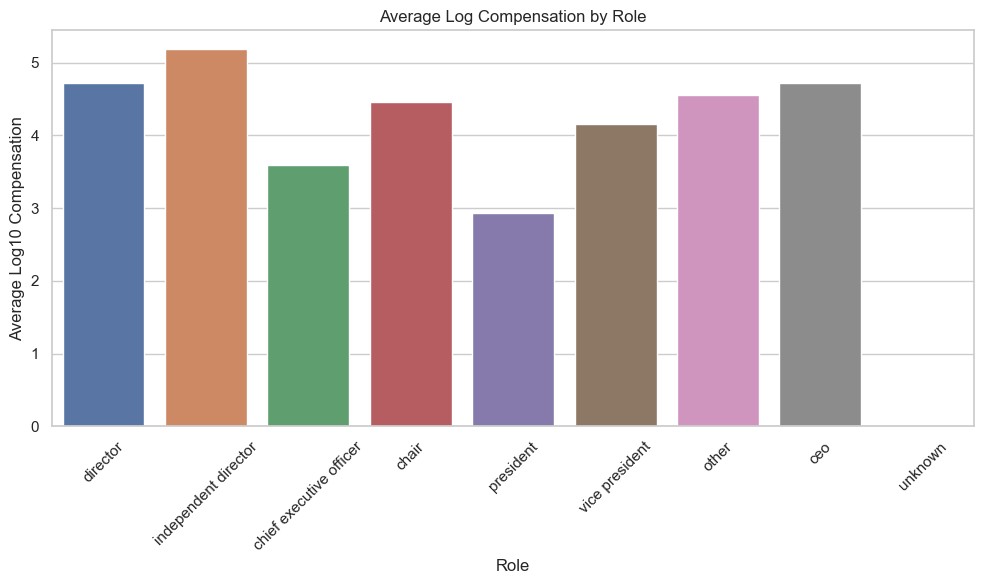

In [76]:
# Plot 2: Average log compensation per role
plt.figure(figsize=(10, 6))
sns.barplot(data=people_data.reset_index(), x='role', y='log_compensation', estimator=np.mean, ci=None, palette='deep')
plt.title('Average Log Compensation by Role')
plt.ylabel('Average Log10 Compensation')
plt.xlabel('Role')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



Average Log Compensation by Role
* Finding:
    * Confirms the same pattern with less distortion from extreme outliers.
* Relevance:
    * Using log compensation helps normalize skewed data—important for regression or network influence modeling.

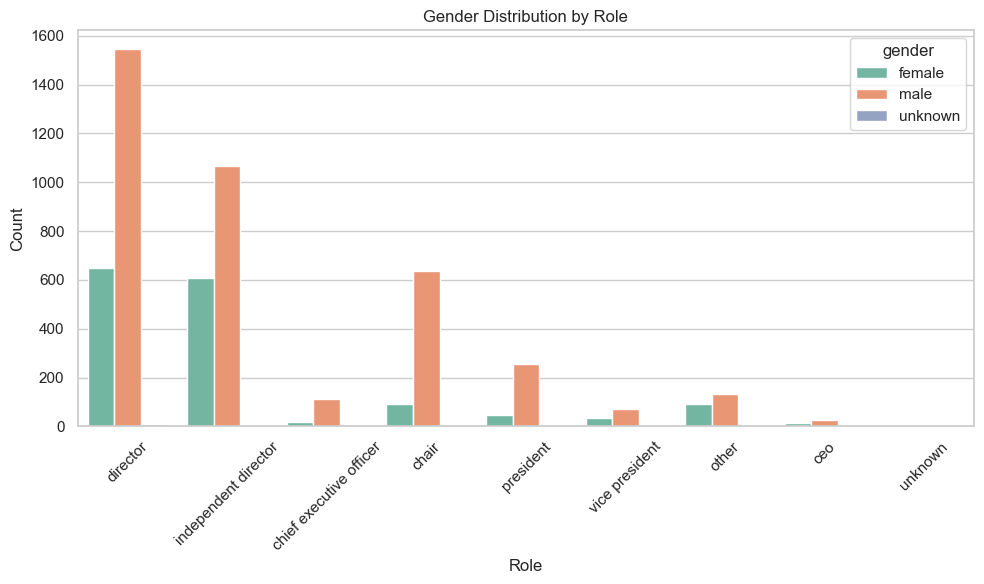

In [80]:
# Plot 3: Gender distribution by role
plt.figure(figsize=(10, 6))
sns.countplot(data=people_data.reset_index(), x='role', hue='gender', palette='Set2')
plt.title('Gender Distribution by Role')
plt.ylabel('Count')
plt.xlabel('Role')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



 Gender Distribution by Role
* Finding:
    * Executive roles like CEO and Chair are male-dominated.
    * Independent Director and Director roles show more gender diversity.
* Relevance:
    * Reveals systemic gender disparities in board hierarchies.
    * Useful for equity analysis or studying how gender affects network position or pay.

/var/folders/t5/9njx8hv90l3_1wy28nrgf7c80000gn/T/ipykernel_67575/2292234037.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=people_data.reset_index(), x='role', y='age', palette='coolwarm')


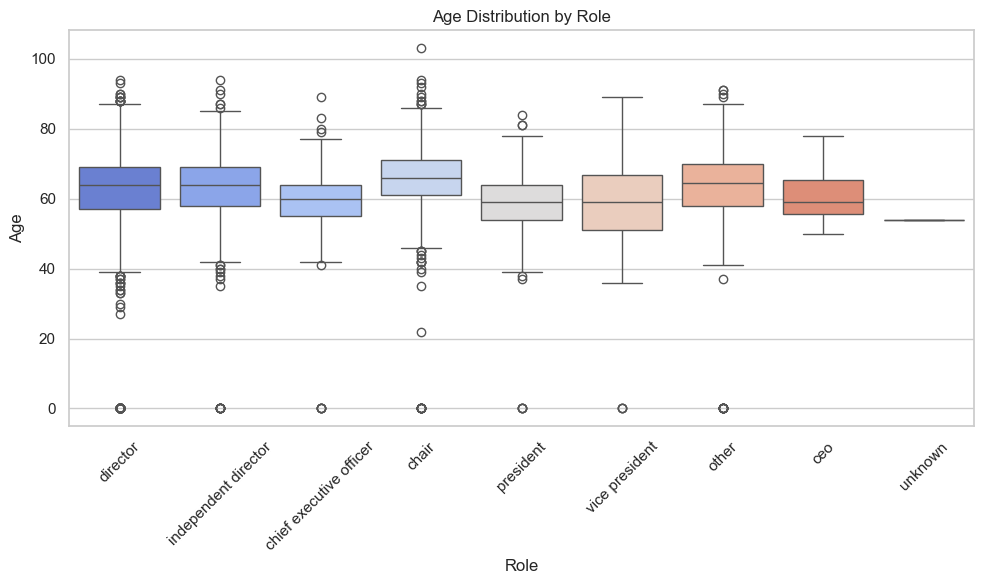

In [82]:
# Plot 4: Age distribution by role (boxplot)
plt.figure(figsize=(10, 6))
sns.boxplot(data=people_data.reset_index(), x='role', y='age', palette='coolwarm')
plt.title('Age Distribution by Role')
plt.ylabel('Age')
plt.xlabel('Role')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Age Distribution by Role
* Finding:
    * Chairs and CEOs are typically older, likely reflecting seniority.
    * Directors and Independent Directors span a broader age range.
* Relevance:
    * Age might correlate with network centrality, tenure, or influence.
    * Important for understanding career stage and board appointment dynamics.

### TASK 4: Complementary dataset

Name: BoardEx – Global Leadership Database

Type: Proprietary (subscription-based) dataset

Source: https://www.boardex.com

Why This Dataset?
BoardEx is a proprietary dataset that contains detailed professional and social network information on board members and senior executives globally, including:

Career history (previous positions, companies, sectors)
Education (universities attended, degrees, graduation year)
Professional connections (who knows whom)
Board tenure (start/end dates on each board)
Additional roles (trusteeships, advisory boards, etc.)

How It Complements the Existing Director Dataset?

| **Data from BoardEx**                                | **How It Complements the Project**                                                                       |
| ---------------------------------------------------- | -------------------------------------------------------------------------------------------------------- |
| Career History                                       | Adds information about past executive roles to analyze how experience affects compensation or centrality |
| Education (universities, degrees)                    | Enables analysis of elite education pathways to influence (e.g., Ivy League → higher centrality)         |
| Board Tenure (start/end dates)                       | Allows study of how long someone has held power — link tenure with influence, compensation               |
| Professional Connections                             | Adds social ties beyond co-board memberships; builds a deeper influence network                          |
| Sector and Industry Involvement                      | Helps analyze cross-sector influence — are some directors bridges between industries?                    |
| Additional Roles (e.g., nonprofits, advisory boards) | Broadens network scope — track how outside roles contribute to overall network power                     |


### TASK 5: Choose two refinement options

(a) Improve the data visualisations and turn this into a presentation that you
could give to a non-technical audience.

(c) Write up your take on the ethics of this project.